In [13]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

In [14]:
#fates_log  = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_logging-mine_phase.Ea8fbc2fc28-F7aa80c14.2025-06-06/run/PA_logging-mine_phase.Ea8fbc2fc28-F7aa80c14.2025-06-06.sofar.nc'
fates_log = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_logging-mine_phase.Ea8fbc2fc28-F7aa80c14.2025-06-12/run/PA_logging-mine_phase.Ea8fbc2fc28-F7aa80c14.2025-06-12.sofar.nc'
fates_log = xr.open_dataset(fates_log, decode_times=False)


In [15]:
nyears = int(len(fates_log.variables['time'])/12)
print(nyears)
#time = np.arange(0,nyears*12,1) / 12
time = fates_log.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

cohort_size_bins = fates_log.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates_log.variables['fates_levage'][:]

70


Text(0.5, 0, 'Time (years)')

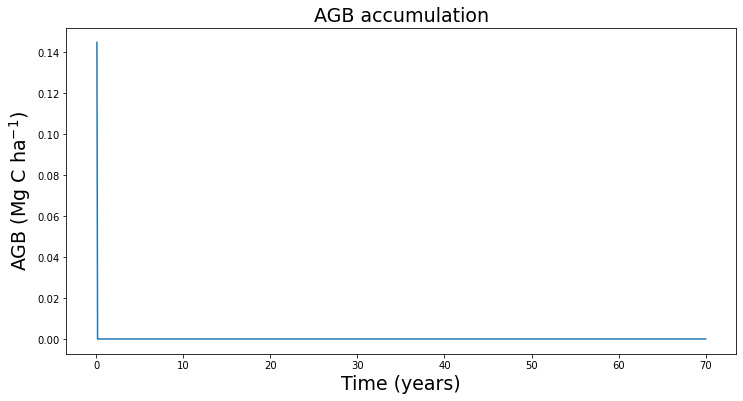

In [16]:

AGB_log = fates_log.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB_log = AGB_log.sum(dim='fates_levscpf')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, AGB_log, label = 'logging') 
f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    


###   Soil carbon

Text(0.5, 0, 'Time (years)')

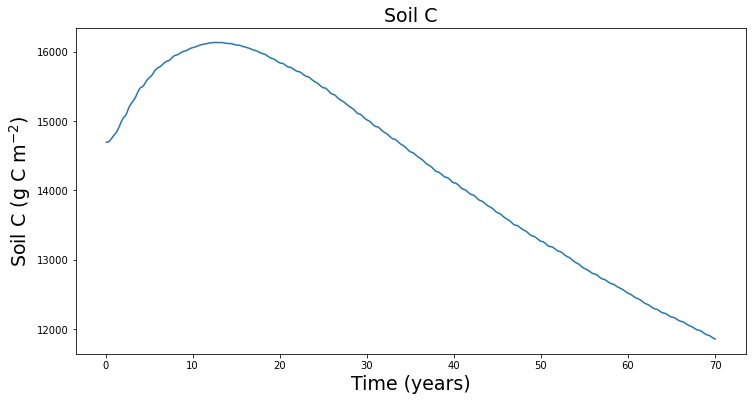

In [17]:
soilC_log = fates_log.SOILC 

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

f1ax0.plot(time, soilC_log, label = 'logging')    
f1ax0.set_title(r'Soil C', fontsize = 19)
f1ax0.set_ylabel(r'Soil C (g C m$^{-2}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)  


### Seed bank

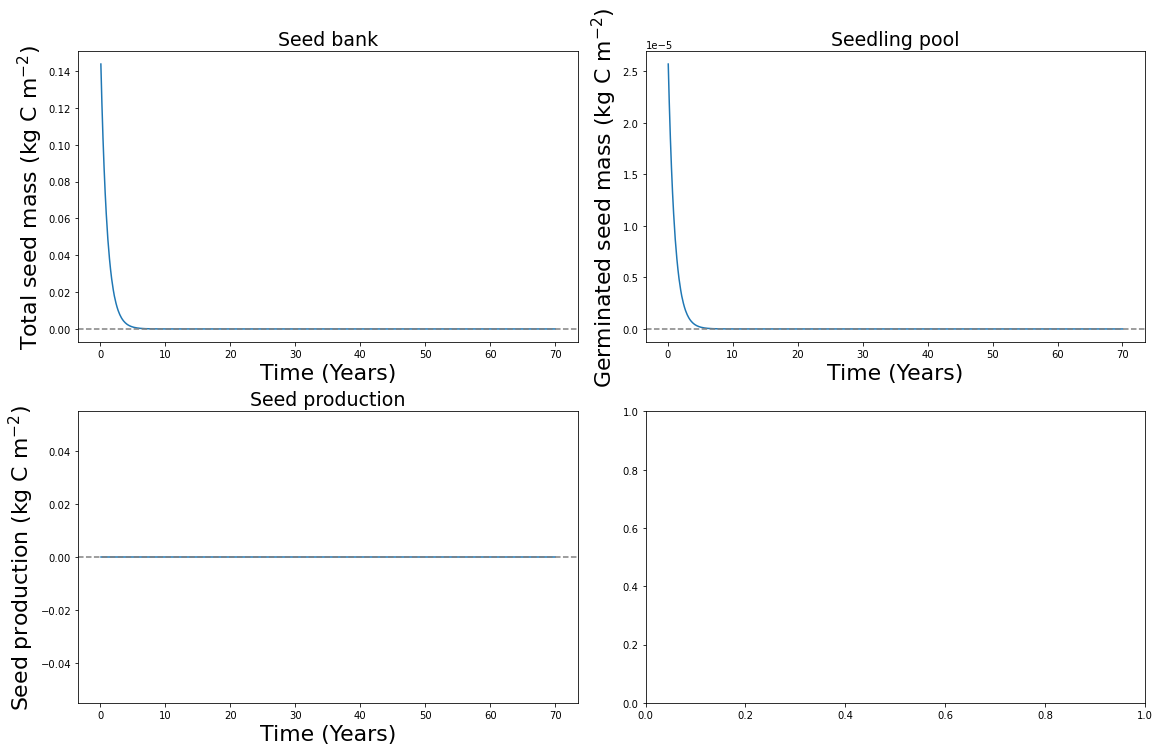

In [18]:
fig1, ((f1ax0, f1ax1), (f1ax2,f1ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(16,10), constrained_layout=True)

f1ax0.plot(time, fates_log.FATES_SEED_BANK)    
f1ax0.set_title(r'Seed bank', fontsize = 19)
f1ax0.set_xlabel(r'Time (Years)', fontsize=22)
f1ax0.set_ylabel(r'Total seed mass (kg C m$^{-2}$)', fontsize=22)
f1ax0.axhline(0, linestyle='--', color='grey')

f1ax1.plot(time, fates_log.FATES_SEEDLING_POOL)    
f1ax1.set_title(r'Seedling pool', fontsize = 19)
f1ax1.set_xlabel(r'Time (Years)', fontsize=22)
f1ax1.set_ylabel(r'Germinated seed mass (kg C m$^{-2}$)', fontsize=22)
f1ax1.axhline(0, linestyle='--', color='grey')

f1ax2.plot(time, fates_log.FATES_SEEDS_IN)    
f1ax2.set_title(r'Seed production', fontsize = 19)
f1ax2.set_xlabel(r'Time (Years)', fontsize=22)
f1ax2.set_ylabel(r'Seed production (kg C m$^{-2}$)', fontsize=22)
f1ax2.axhline(0, linestyle='--', color='grey')